In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Loading Data

In [2]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

import pandas as pd
df_stars = pd.read_csv("stars.csv")

In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_

## Goal

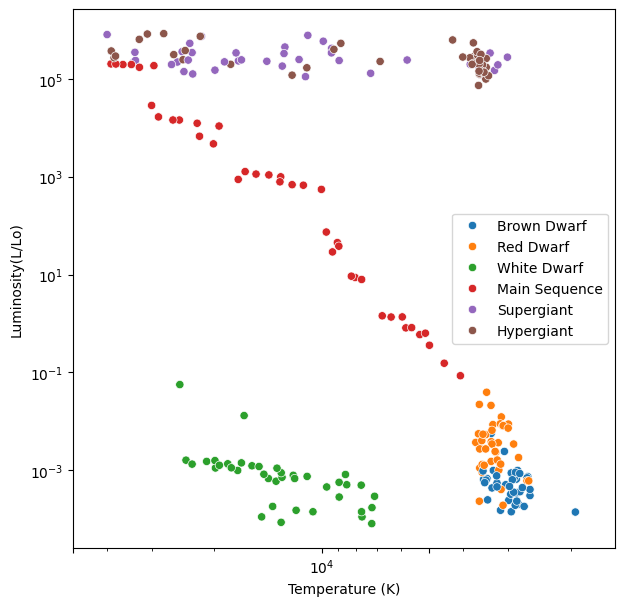

In [4]:
import seaborn as sns

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels, palette='tab10')

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3);

## Without Preprocessing

Expained fractional variance of data encapsulated in the eigenvalues: [9.97606313e-01 2.38789920e-03 5.78677260e-06 1.34274189e-09]


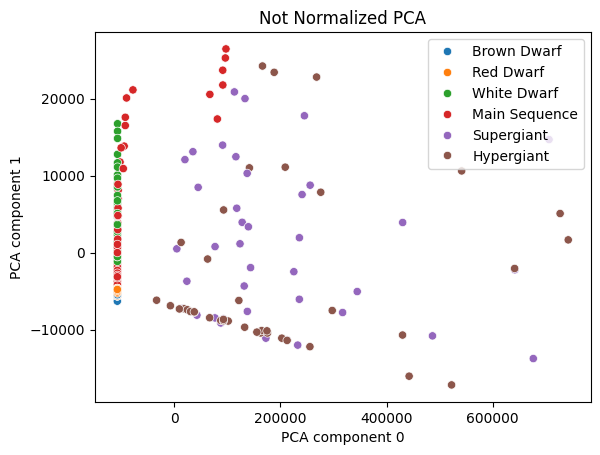

In [5]:
from sklearn.decomposition import PCA
pca = PCA(n_components=4, svd_solver='randomized')

df_stars_data = df_stars.drop(columns=["Star color", "Star type", "Spectral Class"])
X = np.array(df_stars_data)

X=pca.fit_transform(X)

evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels)
plt.xlabel("PCA component 0")
plt.ylabel("PCA component 1");

plt.title("Not Normalized PCA");

## With Preprocessing

Expained fractional variance of data encapsulated in the eigenvalues: [0.60357391 0.23500784 0.09329645 0.0681218 ]


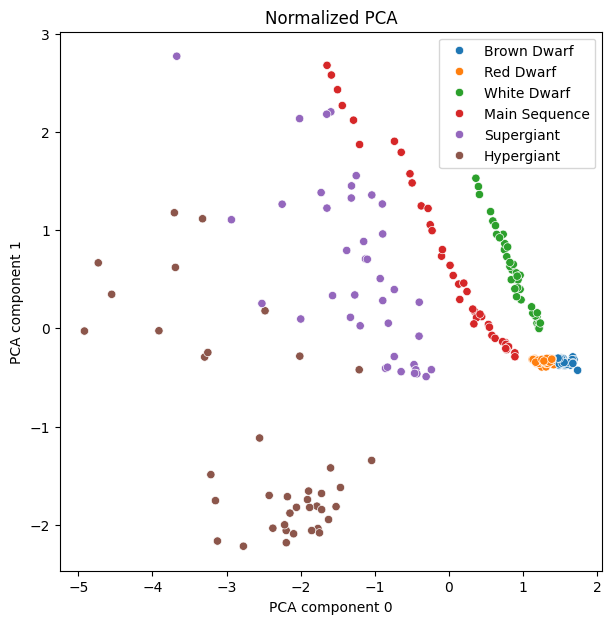

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(df_stars_data)

pca = PCA()
X = pca.fit_transform(X)

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels)
plt.xlabel("PCA component 0")
plt.ylabel("PCA component 1")

evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

plt.title("Normalized PCA");

The first component explains 0.604 of the variance in the data.
The second component explains 0.235 of the variance in the data.
Consequentially, the first two components explain 0.839 of the variance in the data.


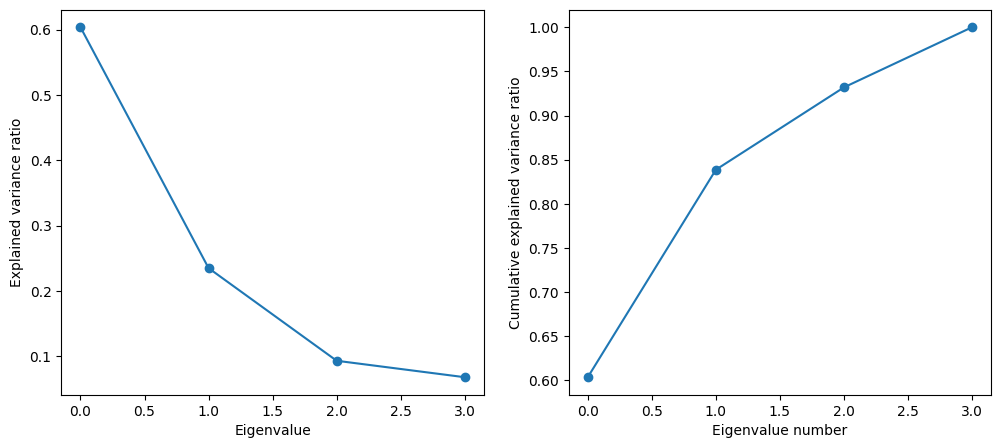

In [7]:
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(121)

n_components=4

ax.plot(np.arange(n_components), evals)
ax.scatter(np.arange(n_components), evals)

ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Explained variance ratio")

ax = fig.add_subplot(122)

ax.plot(np.arange(n_components), evals.cumsum())
ax.scatter(np.arange(n_components), evals.cumsum())

ax.set_xlabel("Eigenvalue number")
ax.set_ylabel("Cumulative explained variance ratio");

print("The first component explains {:.3f} of the variance in the data.".format(pca.explained_variance_ratio_[0]))
print("The second component explains {:.3f} of the variance in the data.".format(pca.explained_variance_ratio_[1]))
print("Consequentially, the first two components explain {:.3f} of the variance in the data.".format(pca.explained_variance_ratio_[0]+pca.explained_variance_ratio_[1]))

We can immediately notice that the first two eigenvalues can give us more than 80% of the information. \
It's not surprising, since the HR diagram is built on the dependence between Temperature and Luminosity for Star systems.